In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Simple Linear Regression

### Data collection

In [3]:
auto=pd.read_csv(r'datasets/auto.csv')

In [4]:
auto.head(10)

,symboling,normalized losses,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


### EDA & Pre-processing

In [13]:
auto.columns

Index(['make', 'fuel type', 'aspiration', 'doors', 'style', 'wheels',
       'engine location', 'wheel base', 'length', 'width', 'height',
       'curb weight', 'engine type', 'cylinders', 'engine size', 'fuel system',
       'bore', 'stroke', 'compression ratio', 'horsepower', 'peak rpm',
       'city mpg', 'highway mpg', 'price'],
      dtype='object')

In [15]:
#auto.drop(['symboling', 'normalized losses'], axis=1,inplace=True)

In [16]:
auto.head(10)

,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,length,width,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [ ]:
auto['fuel type'].unique() #find all distinct (non-repeating) values in a column

array(['gas', 'diesel'], dtype=object)

In [ ]:
auto['horsepower'].unique() #find all distinct (non-repeating) values in a column

array(['111', '154', '102', '115', '110', '140', '160', '101', '121',
       '182', '48', '70', '68', '88', '145', '58', '76', '60', '86',
       '100', '78', '90', '176', '262', '135', '84', '64', '120', '72',
       '123', '155', '184', '175', '116', '69', '55', '97', '152', '200',
       '95', '142', '143', '207', '288', '?', '73', '82', '94', '62',
       '56', '112', '92', '161', '156', '52', '85', '114', '162', '134',
       '106'], dtype=object)

In [6]:
auto_1 = auto[['horsepower', 'price']]

In [20]:
auto_1.head(10)

,horsepower,price
0,111,13495
1,111,16500
2,154,16500
3,102,13950
4,115,17450
5,110,15250
6,110,17710
7,110,18920
8,140,23875
9,160,?


In [7]:
auto_1.replace('?',np.nan,inplace=True) # Replace values inside a df.

C:\Users\nikhi\AppData\Local\Temp\ipykernel_14076\580711913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auto_1.replace('?',np.nan,inplace=True) # Replace values inside a df.


In [24]:
auto_1.tail(10) #tail() funtions to get the top bottom n records or samples.

,horsepower,price
195,114,13415
196,114,15985
197,114,16515
198,162,18420
199,162,18950
200,114,16845
201,160,19045
202,134,21485
203,106,22470
204,114,22625


In [25]:
auto_1['price'].unique()

array(['13495', '16500', '13950', '17450', '15250', '17710', '18920',
       '23875', nan, '16430', '16925', '20970', '21105', '24565', '30760',
       '41315', '36880', '5151', '6295', '6575', '5572', '6377', '7957',
       '6229', '6692', '7609', '8558', '8921', '12964', '6479', '6855',
       '5399', '6529', '7129', '7295', '7895', '9095', '8845', '10295',
       '12945', '10345', '6785', '11048', '32250', '35550', '36000',
       '5195', '6095', '6795', '6695', '7395', '10945', '11845', '13645',
       '15645', '8495', '10595', '10245', '10795', '11245', '18280',
       '18344', '25552', '28248', '28176', '31600', '34184', '35056',
       '40960', '45400', '16503', '5389', '6189', '6669', '7689', '9959',
       '8499', '12629', '14869', '14489', '6989', '8189', '9279', '5499',
       '7099', '6649', '6849', '7349', '7299', '7799', '7499', '7999',
       '8249', '8949', '9549', '13499', '14399', '17199', '19699',
       '18399', '11900', '13200', '12440', '13860', '15580', '16900',


In [26]:
auto_1.dtypes #display the datatypes of the table

horsepower    object
price         object
dtype: object

In [27]:
auto_1.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   horsepower  203 non-null    object
 1   price       201 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [28]:
auto_1.describe() 

,horsepower,price
count,203,201
unique,59,186
top,68,16500
freq,19,2


In [29]:
auto_1.shape

(205, 2)

In [8]:
auto_1['price'] = auto_1['price'].astype('float64')
auto_1['horsepower'] = auto_1['horsepower'].astype('float64')

C:\Users\nikhi\AppData\Local\Temp\ipykernel_14076\964730396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auto_1['price'] = auto_1['price'].astype('float64')
C:\Users\nikhi\AppData\Local\Temp\ipykernel_14076\964730396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auto_1['horsepower'] = auto_1['horsepower'].astype('float64')


In [31]:
auto_1.dtypes

horsepower    float64
price         float64
dtype: object

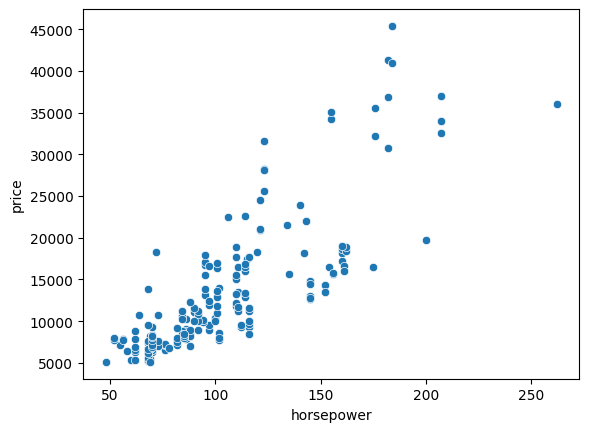

In [9]:
sns.scatterplot(x=auto_1['horsepower'],y=auto_1['price'])
plt.show()
#This is the graph between horsepower and price 

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [11]:
auto_1=auto_1.dropna().reset_index()
#Removes rows that contain at least one missing value
#Resets the index to 0, 1, 2, ...

In [37]:
auto_1.head(10)

,index,horsepower,price
0,0,111.0,13495.0
1,1,111.0,16500.0
2,2,154.0,16500.0
3,3,102.0,13950.0
4,4,115.0,17450.0
5,5,110.0,15250.0
6,6,110.0,17710.0
7,7,110.0,18920.0
8,8,140.0,23875.0
9,10,101.0,16430.0


In [12]:
X = np.array(auto_1['horsepower']).reshape(-1, 1)
y = np.array(auto_1['price'])

In [39]:
X

array([[111.],
       [111.],
       [154.],
       [102.],
       [115.],
       [110.],
       [110.],
       [110.],
       [140.],
       [101.],
       [101.],
       [121.],
       [121.],
       [121.],
       [182.],
       [182.],
       [182.],
       [ 48.],
       [ 70.],
       [ 70.],
       [ 68.],
       [ 68.],
       [102.],
       [ 68.],
       [ 68.],
       [ 68.],
       [102.],
       [ 88.],
       [145.],
       [ 58.],
       [ 76.],
       [ 60.],
       [ 76.],
       [ 76.],
       [ 76.],
       [ 76.],
       [ 86.],
       [ 86.],
       [ 86.],
       [ 86.],
       [101.],
       [100.],
       [ 78.],
       [ 90.],
       [176.],
       [176.],
       [262.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [101.],
       [101.],
       [101.],
       [135.],
       [ 84.],
       [ 84.],
       [ 84.],
       [ 84.],
       [ 64.],
       [ 84.],
       [120.],
       [ 72.],
       [123.],
       [123.],
       [12

In [40]:
y

array([13495., 16500., 16500., 13950., 17450., 15250., 17710., 18920.,
       23875., 16430., 16925., 20970., 21105., 24565., 30760., 41315.,
       36880.,  5151.,  6295.,  6575.,  5572.,  6377.,  7957.,  6229.,
        6692.,  7609.,  8558.,  8921., 12964.,  6479.,  6855.,  5399.,
        6529.,  7129.,  7295.,  7295.,  7895.,  9095.,  8845., 10295.,
       12945., 10345.,  6785., 11048., 32250., 35550., 36000.,  5195.,
        6095.,  6795.,  6695.,  7395., 10945., 11845., 13645., 15645.,
        8845.,  8495., 10595., 10245., 10795., 11245., 18280., 18344.,
       25552., 28248., 28176., 31600., 34184., 35056., 40960., 45400.,
       16503.,  5389.,  6189.,  6669.,  7689.,  9959.,  8499., 12629.,
       14869., 14489.,  6989.,  8189.,  9279.,  9279.,  5499.,  7099.,
        6649.,  6849.,  7349.,  7299.,  7799.,  7499.,  7999.,  8249.,
        8949.,  9549., 13499., 14399., 13499., 17199., 19699., 18399.,
       11900., 13200., 12440., 13860., 15580., 16900., 16695., 17075.,
      

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, 
                                                    train_size=0.8, 
                                                    test_size=0.20
                                                    )

### Model Building

In [14]:
reg = LinearRegression() #initializing a Linear Regression Class

In [15]:
reg_fit_main = reg.fit(X_train, y_train) #training the model # building the line equation y=mx+c

In [16]:
reg.coef_ #model coefficients or parameters y=mx+c, x--> cooefficient
#y--> intercept

array([165.44814799])

In [17]:
reg.intercept_ #model intercept 

np.float64(-4153.2863567156655)

### Model evaluation

In [18]:
r_square = reg_fit_main.score(X_train, y_train)
print('Model R-Squared:', r_square)

Model R-Squared: 0.6800355652221743


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [20]:
y_predicted = reg_fit_main.predict(X_test) #By using X_test data we are predicting y 

In [21]:
#After predicting the y then comparing with y_test data
print("Model Evalutation Metics")
print("=========================")
print("MSE: ", round(mean_squared_error(y_test, y_predicted),2))
print("MAE: ", round(mean_absolute_error(y_test, y_predicted),2))
print("MAPE: ", round(mean_absolute_percentage_error(y_test, y_predicted),2))

Model Evalutation Metics
MSE:  37407316.68
MAE:  4262.21
MAPE:  0.26


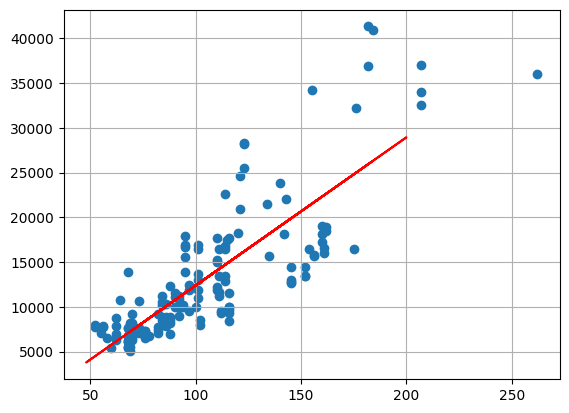

In [ ]:
plt.scatter(X_train,y_train) #Ploting scatter plot for train data
plt.plot(X_test, y_predicted,'r')#Ploting line of test data and predicted data || #'r'--> specifing the colour of the line
plt.grid(True)
plt.show()